In [6]:
of_measurements = [    0.884,
    0.912,
    0.955,
    0.971,
    1.000,
    1.021,
    1.045,
    1.075,
    0.939,
    0.963
]

In [ ]:
from sympy import false
import torch
import numpy as np
import matplotlib.pyplot as plt
import math
import pydicom
from pydose_rt import DoseEngine
from pydose_rt.data import MachineConfig, Phantom, loaders, Beam
from pydose_rt.utils.utils import sample_tensor_nearest

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
dtype=torch.float32

do_plot = True

kernel_size = 101
field_sizes = [[40, 40], [50, 50], [70, 70], [80, 80], [100, 100], [120, 120], [150, 150], [200, 200], [400, 50], [50, 400]]
results =  []

machine_config = MachineConfig(
    preset="../../src/pydose_rt/data/machine_presets/umea_10MV.json", 
    head_scatter_amplitude=None,
    output_factors=None,
    head_scatter_sigma=None,
    profile_corrections=None)
resolution = (4.0, 4.0, 4.0)
ct_array_shape = (100, 100, 100)
phantom = Phantom.from_uniform_water(shape=ct_array_shape, spacing=resolution).to(device).to(dtype)
beam_template = Beam.create(
    gantry_angle_deg=0.0, 
    number_of_leaf_pairs=60, 
    collimator_angle_deg=0.0, 
    field_size_mm=(100, 100), 
    iso_center=(0.0, -102.0, 0.0), 
    device=device, 
    dtype=dtype)
dose_engine = DoseEngine(
    machine_config, 
    kernel_size,
    resolution=phantom._resolution,
    image_template=phantom.density_image,
    beam_template=beam_template,
    device=device,
    dtype=dtype,
    adjust_values=False
)
dose_engine.calibrate(110)
for field_size in field_sizes:
    number_of_beams=1
    starting_angle=0

    beam = Beam.create(
        gantry_angle_deg=0.0, 
        number_of_leaf_pairs=60, 
        collimator_angle_deg=0.0, 
        field_size_mm=(field_size[0], field_size[1]), 
        iso_center=(0.0, -102.0, 0.0), 
        device=device, 
        dtype=dtype)
    beam.mu = 110 * beam.mu

    dose = dose_engine.compute_dose(
        beam,
        ct_image=phantom.density_image).detach()
    # plt.plot(dose[0, 50, :, 50].cpu().detach().numpy())
    # plt.show()
    results.append(dose[0, *dose_engine.iso_center_voxel].item())
                            

Calibration failed. Adjusting calibration factor to: 0.004177252812265523


In [13]:
result_ratios = np.array(of_measurements) / np.array(results)

k_X = 0.718705, k_Y = 0.453383

=== Refit including 40x5 and 5x40 ===
Scatter fraction at 10x10 (S): 7.84 %
Primary fraction at 10x10:    92.16 %
Sigma_FF (cm):                1.4822

Field size      Measured Sc     Fitted Sc
 4.0x 4.0    0.951149850   0.949579200
 5.0x 5.0    0.966257875   0.960831991
 7.0x 7.0    0.985839691   0.980970733
 8.0x 8.0    0.992452903   0.988853228
10.0x10.0    1.002415697   1.000000000
12.0x12.0    1.008014997   1.006348461
15.0x15.0    1.011695815   1.010700175
20.0x20.0    1.017550759   1.012505915
40.0x 4.0    0.955614851   0.963471903
 4.0x40.0    0.979430127   0.982461443

=== Geometric penumbra from FF scatter body ===
sigma_X_geom (crossline) = 2.3957 cm  (FWHM 5.6418 cm)
sigma_Y_geom (inline)    = 4.1943 cm  (FWHM 9.8776 cm)

=== Convolution kernel sigmas at isocenter ===
sigma_x_conv = 2.3957 cm
sigma_y_conv = 4.1943 cm


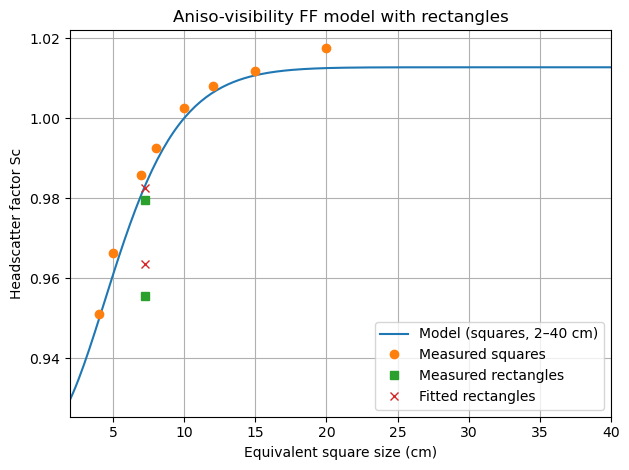

: 

In [ ]:
import numpy as np
from scipy.special import erf
from scipy.optimize import least_squares
import matplotlib.pyplot as plt

# =========================================================
# 1. Geometry
# =========================================================
d_iso = 100.0   # source-to-isocenter distance (cm)
d_FF  = 10.0    # source-to-flattening-filter distance (cm)
d_Y   = 33.5    # source-to-Y-jaw distance (cm)
d_X   = 44.4    # source-to-X-jaw distance (cm)

# Anisotropic geometry factors for FF visibility
k_X = d_X * (d_iso - d_FF) / (d_iso * (d_iso - d_X))
k_Y = d_Y * (d_iso - d_FF) / (d_iso * (d_iso - d_Y))

print(f"k_X = {k_X:.6f}, k_Y = {k_Y:.6f}")

# =========================================================
# 2. Measured Sc data
# =========================================================
# Square fields (X = Y)
ax_sq = np.array([4., 5., 7., 8., 10., 12., 15., 20.])
ay_sq = ax_sq.copy()
Sc_sq = result_ratios[:8]

# Rectangular fields
ax_rect = np.array([40., 4.])
ay_rect = np.array([4., 40.])
Sc_rect_meas = result_ratios[8:]

# Combine all fields
ax_all = np.concatenate([ax_sq, ax_rect])
ay_all = np.concatenate([ay_sq, ay_rect])
# Sc_all = np.concatenate([Sc_sq, Sc_rect_meas])

# Index of the 10x10 reference field
ref_idx = np.where((ax_all == 10.0) & (ay_all == 10.0))[0][0]

# =========================================================
# 3. Visibility model for an FF Gaussian
# =========================================================
def f_frac_visibility_rect(ax, ay, sigma_FF):
    """
    Fraction of a 2D Gaussian (width sigma_FF) at the FF plane
    that is visible through the jaws for a rectangular field
    ax x ay at isocenter, given jaw depths and geometry.

    ax, ay: field side lengths at isocenter (cm)
    sigma_FF: Gaussian sigma at FF plane (cm)
    """
    hx = 0.5 * ax
    hy = 0.5 * ay

    # Half-widths of visible region at FF along X and Y
    wX = hx * k_X
    wY = hy * k_Y

    return erf(wX / (np.sqrt(2.0) * sigma_FF)) * \
           erf(wY / (np.sqrt(2.0) * sigma_FF))


def Sc_model_aniso_rect(p):
    """
    Headscatter Sc model with:
      - one isotropic Gaussian source at FF (sigma_FF)
      - anisotropic jaw-limited visibility (k_X, k_Y)
      - single scatter fraction S at 10x10.

    Parameters p:
      p[0] -> u (logit for scatter fraction S)
      p[1] -> logsigma_FF
    """
    u, logsigma = p

    # Scatter fraction at 10x10 (0..1)
    S = 1.0 / (1.0 + np.exp(-u))

    # Sigma at FF (>= 0.01 cm)
    sigma_FF = 0.01 + np.exp(logsigma)

    # Visibility fractions for all fields
    f_all = f_frac_visibility_rect(ax_all, ay_all, sigma_FF)
    f_ref = f_all[ref_idx]

    # Sc = primary + scatter, normalized so Sc_ref = 1
    Sc = (1.0 - S) + S * (f_all / f_ref)
    return Sc


def residuals_aniso_rect(p):
    return Sc_model_aniso_rect(p) - Sc_all


# =========================================================
# 4. Fit S and sigma_FF
# =========================================================
S_guess = 0.055
sigma_guess = 1.9  # cm
p0 = np.array([
    np.log(S_guess / (1 - S_guess)),  # logit for S
    np.log(sigma_guess)               # logsigma
])

res_rect = least_squares(residuals_aniso_rect, p0)
u_fit_r, logsigma_fit_r = res_rect.x

S_fit = 1.0 / (1.0 + np.exp(-u_fit_r))
sigma_FF_fit = 0.01 + np.exp(logsigma_fit_r)

print("\n=== Refit including 40x5 and 5x40 ===")
print(f"Scatter fraction at 10x10 (S): {S_fit*100:.2f} %")
print(f"Primary fraction at 10x10:    {(1.0 - S_fit)*100:.2f} %")
print(f"Sigma_FF (cm):                {sigma_FF_fit:.4f}")

# Model Sc for all fields
Sc_fit_all = Sc_model_aniso_rect(res_rect.x)

print("\nField size      Measured Sc     Fitted Sc")
for ax, ay, sc_m, sc_f in zip(ax_all, ay_all, Sc_all, Sc_fit_all):
    print(f"{ax:4.1f}x{ay:4.1f}    {sc_m:0.9f}   {sc_f:0.9f}")

# =========================================================
# 5. Compute equivalent square sizes for plotting
# =========================================================
def equivalent_square(ax, ay):
    return 2 * ax * ay / (ax + ay)

eq_sq_sq   = equivalent_square(ax_sq, ay_sq)
eq_sq_rect = equivalent_square(ax_rect, ay_rect)

# Model curve for square fields from 2–40 cm
a_plot = np.linspace(2.0, 40.0, 200)
f_plot = f_frac_visibility_rect(a_plot, a_plot, sigma_FF_fit)
f_ref = f_frac_visibility_rect(10.0, 10.0, sigma_FF_fit)
Sc_plot_sq = (1.0 - S_fit) + S_fit * (f_plot / f_ref)

# =========================================================
# 6. Geometric penumbra sigmas at isocenter (X and Y)
# =========================================================
def geom_penum_sigma(sigma_FF, d_iso, d_FF, d_jaw):
    """
    Geometric penumbra sigma at isocenter due to a finite
    scattering body at d_FF, limited by a jaw at d_jaw.
    """
    return sigma_FF * (d_iso - d_jaw) / (d_jaw - d_FF)

sigma_X_geom = geom_penum_sigma(sigma_FF_fit, d_iso, d_FF, d_X)
sigma_Y_geom = geom_penum_sigma(sigma_FF_fit, d_iso, d_FF, d_Y)

FWHM_X = 2.355 * sigma_X_geom
FWHM_Y = 2.355 * sigma_Y_geom

print("\n=== Geometric penumbra from FF scatter body ===")
print(f"sigma_X_geom (crossline) = {sigma_X_geom:.4f} cm  (FWHM {FWHM_X:.4f} cm)")
print(f"sigma_Y_geom (inline)    = {sigma_Y_geom:.4f} cm  (FWHM {FWHM_Y:.4f} cm)")

# These are the anisotropic sigmas to convolve the primary fluence with
sigma_x_conv = sigma_X_geom
sigma_y_conv = sigma_Y_geom

print("\n=== Convolution kernel sigmas at isocenter ===")
print(f"sigma_x_conv = {sigma_x_conv:.4f} cm")
print(f"sigma_y_conv = {sigma_y_conv:.4f} cm")

# =========================================================
# 7. Plot: model vs data (using equivalent square on x-axis)
# =========================================================
plt.figure()
plt.plot(a_plot, Sc_plot_sq, '-', label='Model (squares, 2–40 cm)')
plt.plot(eq_sq_sq, Sc_sq, 'o', label='Measured squares')

plt.plot(eq_sq_rect, Sc_rect_meas, 's', label='Measured rectangles')
plt.plot(eq_sq_rect, Sc_fit_all[-2:], 'x', label='Fitted rectangles')

plt.xlabel('Equivalent square size (cm)')
plt.ylabel('Headscatter factor Sc')
plt.title('Aniso-visibility FF model with rectangles')
plt.grid(True)
plt.legend()
plt.xlim(2, 40)
plt.tight_layout()
plt.show()